# So sánh tổng hợp các phương pháp chọn đặc trưng (v2)

Notebook này tổng hợp kết quả từ baseline, kbest, rfe, model-based để đưa ra bộ đặc trưng cuối cùng cho bước tuning.

## 1. Import thư viện

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 2. Xác định đường dẫn và đọc kết quả

In [ ]:
đường_dẫn_metrics_ứng_viên = [
    Path("../../outputs/metrics"),
    Path("../outputs/metrics"),
    Path("outputs/metrics"),
    Path("AbaloneAge/outputs/metrics"),
]

đường_dẫn_metrics = None
for p in đường_dẫn_metrics_ứng_viên:
    p_đầy_đủ = p.resolve()
    if p_đầy_đủ.exists():
        đường_dẫn_metrics = p_đầy_đủ
        break

if đường_dẫn_metrics is None:
    raise FileNotFoundError(
        "Không tìm thấy thư mục outputs/metrics. Hãy chạy baseline, kbest, rfe, model-based trước."
    )

tập_tin_cần = {
    "baseline": đường_dẫn_metrics / "03_baseline_feature_scores.csv",
    "kbest": đường_dẫn_metrics / "03_kbest_feature_scores.csv",
    "rfe": đường_dẫn_metrics / "03_rfe_feature_ranking.csv",
    "model_based": đường_dẫn_metrics / "03_model_based_feature_ranking.csv",
}

for tên, p in tập_tin_cần.items():
    if not p.exists():
        raise FileNotFoundError(f"Thiếu file {tên}: {p}")

df_baseline = pd.read_csv(tập_tin_cần["baseline"])
df_kbest = pd.read_csv(tập_tin_cần["kbest"])
df_rfe = pd.read_csv(tập_tin_cần["rfe"])
df_model = pd.read_csv(tập_tin_cần["model_based"])

print("Thư mục metrics:", đường_dẫn_metrics)
print("Baseline  :", df_baseline.shape)
print("KBest     :", df_kbest.shape)
print("RFE       :", df_rfe.shape)
print("ModelBased:", df_model.shape)

Thu muc metrics: C:\Users\Admin\Documents\GitHub\TNTT_Repo_Abalone6\AbaloneAge\outputs\metrics
Baseline  : (8, 9)
KBest     : (10, 3)
RFE       : (10, 3)
ModelBased: (10, 2)


## 3. Hàm chuẩn hóa tên đặc trưng

In [ ]:
def chuẩn_hóa_tên_đặc_trưng(tên):
    t = str(tên)

    # Bỏ prefix do ColumnTransformer tạo ra
    for prefix in ["so__", "hang_muc__one_hot__", "hang_muc__"]:
        if t.startswith(prefix):
            t = t[len(prefix):]

    # Gộp one-hot giới tính về một biến tổng quát 'sex'
    if t.startswith("sex_"):
        return "sex"

    return t

## 4. Tạo điểm cho từng phương pháp

In [ ]:
# Baseline
cột_tên_baseline = "đặc_trưng" if "đặc_trưng" in df_baseline.columns else "dac_trung"
cột_điểm_baseline = "tương_quan" if "tương_quan" in df_baseline.columns else "tuong_quan"

bảng_baseline = df_baseline[[cột_tên_baseline, cột_điểm_baseline]].copy()
bảng_baseline.columns = ["đặc_trưng_gốc", "điểm_gốc"]
bảng_baseline["đặc_trưng"] = bảng_baseline["đặc_trưng_gốc"].apply(chuẩn_hóa_tên_đặc_trưng)
bảng_baseline = bảng_baseline.groupby("đặc_trưng", as_index=False)["điểm_gốc"].max()
bảng_baseline["baseline_score"] = bảng_baseline["điểm_gốc"] / (bảng_baseline["điểm_gốc"].max() + 1e-12)
bảng_baseline = bảng_baseline[["đặc_trưng", "baseline_score"]]

# KBest
bảng_kbest = df_kbest[["dac_trung", "diem_f"]].copy()
bảng_kbest["đặc_trưng"] = bảng_kbest["dac_trung"].apply(chuẩn_hóa_tên_đặc_trưng)
bảng_kbest = bảng_kbest.groupby("đặc_trưng", as_index=False)["diem_f"].max()
bảng_kbest["kbest_score"] = bảng_kbest["diem_f"] / (bảng_kbest["diem_f"].max() + 1e-12)
bảng_kbest = bảng_kbest[["đặc_trưng", "kbest_score"]]

# RFE
bảng_rfe = df_rfe[["dac_trung", "duoc_chon", "xep_hang_rfe"]].copy()
bảng_rfe["đặc_trưng"] = bảng_rfe["dac_trung"].apply(chuẩn_hóa_tên_đặc_trưng)
max_rank = bảng_rfe["xep_hang_rfe"].max()
bảng_rfe["rfe_score_raw"] = np.where(
    bảng_rfe["duoc_chon"] == True,
    (max_rank - bảng_rfe["xep_hang_rfe"] + 1) / (max_rank + 1e-12),
    0.0,
)
bảng_rfe = bảng_rfe.groupby("đặc_trưng", as_index=False)["rfe_score_raw"].max()
bảng_rfe["rfe_score"] = bảng_rfe["rfe_score_raw"] / (bảng_rfe["rfe_score_raw"].max() + 1e-12)
bảng_rfe = bảng_rfe[["đặc_trưng", "rfe_score"]]

# Model-based
bảng_model = df_model[["dac_trung", "diem_trung_binh"]].copy()
bảng_model["đặc_trưng"] = bảng_model["dac_trung"].apply(chuẩn_hóa_tên_đặc_trưng)
bảng_model = bảng_model.groupby("đặc_trưng", as_index=False)["diem_trung_binh"].max()
bảng_model["model_score"] = bảng_model["diem_trung_binh"] / (bảng_model["diem_trung_binh"].max() + 1e-12)
bảng_model = bảng_model[["đặc_trưng", "model_score"]]

## 5. Gộp điểm và xếp hạng tổng

In [ ]:
bảng_tổng = bảng_baseline.merge(bảng_kbest, on="đặc_trưng", how="outer")
bảng_tổng = bảng_tổng.merge(bảng_rfe, on="đặc_trưng", how="outer")
bảng_tổng = bảng_tổng.merge(bảng_model, on="đặc_trưng", how="outer")

for c in ["baseline_score", "kbest_score", "rfe_score", "model_score"]:
    if c not in bảng_tổng.columns:
        bảng_tổng[c] = 0.0

bảng_tổng = bảng_tổng.fillna(0.0)
bảng_tổng["tổng_điểm"] = bảng_tổng[["baseline_score", "kbest_score", "rfe_score", "model_score"]].mean(axis=1)
bảng_tổng = bảng_tổng.sort_values(by="tổng_điểm", ascending=False).reset_index(drop=True)
bảng_tổng["xếp_hạng"] = np.arange(1, len(bảng_tổng) + 1)

bảng_tổng.head(15)

,dac_trung,baseline_score,kbest_score,rfe_score,model_score,tong_diem,xep_hang
0,shell_weight,1.000000,1.000000,1.0,1.000000,1.000000,1
1,whole_weight,0.861077,0.624895,1.0,0.712122,0.799523,2
2,diameter,0.915685,0.735749,1.0,0.333492,0.746231,3
3,shucked_weight,0.670652,0.322484,1.0,0.823052,0.704047,4
4,height,0.888289,0.654777,1.0,0.256458,0.699881,5
5,viscera_weight,0.802804,0.517642,1.0,0.319703,0.660037,6
6,length,0.887098,0.676125,0.0,0.221510,0.446183,7
7,sex,0.055176,0.331571,1.0,0.182593,0.392335,8


## 6. Trực quan hóa so sánh

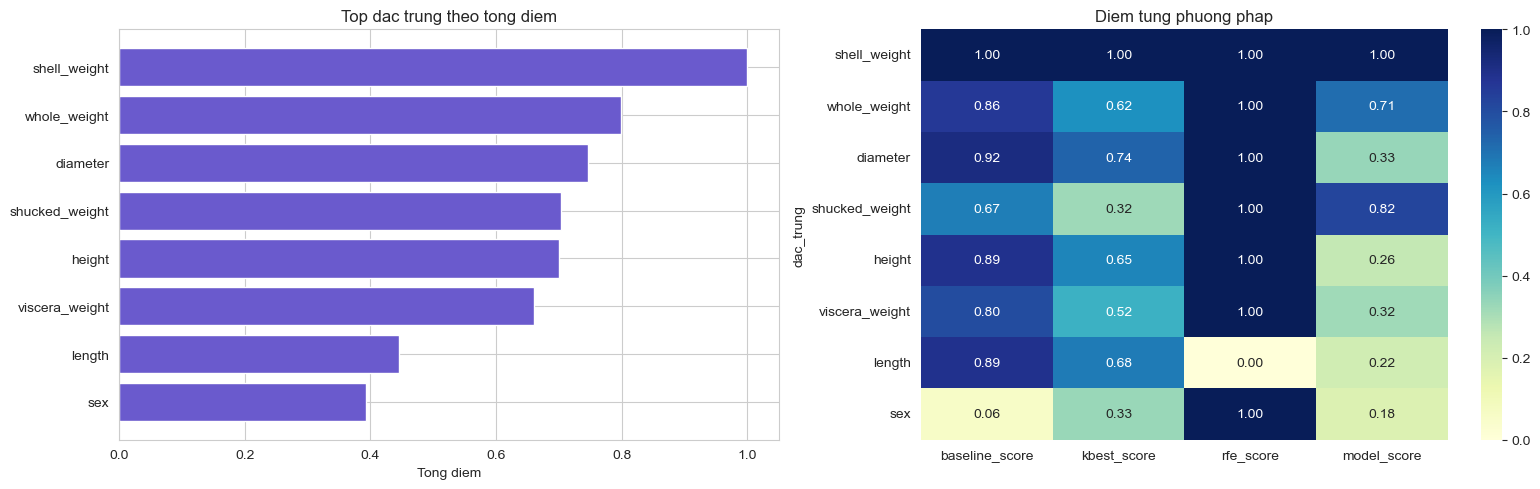

Da luu hinh: 03_feature_selection_compare_v2.png


In [ ]:
top_n = min(12, len(bảng_tổng))
bảng_top = bảng_tổng.head(top_n).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Biểu đồ cột tổng điểm
bảng_bar = bảng_top.sort_values(by="tổng_điểm")
axes[0].barh(bảng_bar["đặc_trưng"], bảng_bar["tổng_điểm"], color="slateblue")
axes[0].set_title("Top đặc trưng theo tổng điểm")
axes[0].set_xlabel("Tổng điểm")

# Heatmap điểm theo phương pháp
dữ_liệu_heatmap = bảng_top.set_index("đặc_trưng")[["baseline_score", "kbest_score", "rfe_score", "model_score"]]
sns.heatmap(dữ_liệu_heatmap, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Điểm từng phương pháp")

plt.tight_layout()
đường_dẫn_hình = (đường_dẫn_metrics.parent / "figures").resolve()
đường_dẫn_hình.mkdir(parents=True, exist_ok=True)
plt.savefig(đường_dẫn_hình / "03_feature_selection_compare_v2.png", dpi=300, bbox_inches="tight")
plt.show()

print("Đã lưu hình: 03_feature_selection_compare_v2.png")

## 7. Chọn bộ đặc trưng đề xuất

In [ ]:
số_đặc_trưng_đề_xuất = min(6, len(bảng_tổng))
bộ_đề_xuất = bảng_tổng.head(số_đặc_trưng_đề_xuất).copy()

print("Bộ đặc trưng đề xuất cuối cùng:")
for i, row in bộ_đề_xuất.iterrows():
    print(f"{int(row['xếp_hạng']):>2}. {row['đặc_trưng']:<20} | tổng_điểm={row['tổng_điểm']:.3f}")

bộ_đề_xuất

Bo dac trung de xuat cuoi cung:
 1. shell_weight         | tong_diem=1.000
 2. whole_weight         | tong_diem=0.800
 3. diameter             | tong_diem=0.746
 4. shucked_weight       | tong_diem=0.704
 5. height               | tong_diem=0.700
 6. viscera_weight       | tong_diem=0.660


,dac_trung,baseline_score,kbest_score,rfe_score,model_score,tong_diem,xep_hang
0,shell_weight,1.000000,1.000000,1.0,1.000000,1.000000,1
1,whole_weight,0.861077,0.624895,1.0,0.712122,0.799523,2
2,diameter,0.915685,0.735749,1.0,0.333492,0.746231,3
3,shucked_weight,0.670652,0.322484,1.0,0.823052,0.704047,4
4,height,0.888289,0.654777,1.0,0.256458,0.699881,5
5,viscera_weight,0.802804,0.517642,1.0,0.319703,0.660037,6


## 8. Đọc metric tổng kết để đối chiếu (nếu có)

In [ ]:
đường_dẫn_json = {
    "baseline": đường_dẫn_metrics / "03_baseline_summary.json",
    "kbest": đường_dẫn_metrics / "03_kbest_summary.json",
    "rfe": đường_dẫn_metrics / "03_rfe_summary.json",
    "model_based": đường_dẫn_metrics / "03_model_based_summary.json",
}

dòng = []
for tên, p in đường_dẫn_json.items():
    if p.exists():
        with open(p, "r", encoding="utf-8") as f:
            data = json.load(f)

        test = data.get("test", {})
        dòng.append({
            "phương_pháp": tên,
            "MAE": test.get("MAE", np.nan),
            "RMSE": test.get("RMSE", np.nan),
            "R2": test.get("R2", np.nan),
        })

if len(dòng) > 0:
    bảng_metric = pd.DataFrame(dòng).sort_values(by="RMSE")
    display(bảng_metric)
else:
    bảng_metric = pd.DataFrame(columns=["phương_pháp", "MAE", "RMSE", "R2"])
    print("Không tìm thấy file summary json để đối chiếu metric.")

,phuong_phap,MAE,RMSE,R2
2,rfe,1.545546,2.145583,0.551510
1,kbest,1.545080,2.145676,0.551471
3,model_based,1.545080,2.145676,0.551471
0,baseline,NaN,NaN,NaN


## 9. Lưu kết quả tổng hợp

In [ ]:
bảng_tổng.to_csv(đường_dẫn_metrics / "03_compare_v2_feature_scores.csv", index=False)
bộ_đề_xuất.to_csv(đường_dẫn_metrics / "03_compare_v2_selected_features.csv", index=False)

if len(bảng_metric) > 0:
    bảng_metric.to_csv(đường_dẫn_metrics / "03_compare_v2_method_metrics.csv", index=False)

tóm_tắt = {
    "phương_pháp": "compare_v2",
    "số_đặc_trưng_đề_xuất": int(len(bộ_đề_xuất)),
    "đặc_trưng_đề_xuất": bộ_đề_xuất["đặc_trưng"].tolist(),
    "top_10": bảng_tổng.head(10).to_dict(orient="records"),
}

with open(đường_dẫn_metrics / "03_compare_v2_summary.json", "w", encoding="utf-8") as f:
    json.dump(tóm_tắt, f, ensure_ascii=False, indent=2)

print("Đã lưu: 03_compare_v2_feature_scores.csv")
print("Đã lưu: 03_compare_v2_selected_features.csv")
if len(bảng_metric) > 0:
    print("Đã lưu: 03_compare_v2_method_metrics.csv")
print("Đã lưu: 03_compare_v2_summary.json")

Da luu: 03_compare_v2_feature_scores.csv
Da luu: 03_compare_v2_selected_features.csv
Da luu: 03_compare_v2_method_metrics.csv
Da luu: 03_compare_v2_summary.json
